In [1]:
import warnings
warnings.filterwarnings("ignore")

import copy
import os
import time

import crepe
import ddsp
import ddsp.training
from ddsp.training.postprocessing import (
    detect_notes, fit_quantile_transform
)
from ddsp.training import (data, decoders, encoders, models, preprocessing, 
                           train_util, trainers)
import gin
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
import pickle
import tensorflow.compat.v2 as tf
import tensorflow_datasets as tfds
import soundfile as sf
import scipy.linalg
import magenta

print('Done!')

2025-05-11 03:47:56.938108: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-05-11 03:47:57.067766: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory
2025-05-11 03:47:57.067800: I tensorflow/compiler/xla/stream_executor/cuda/cudart_stub.cc:29] Ignore above cudart dlerror if you do not have a GPU set up on your machine.
2025-05-11 03:47:58.067970: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libnvinfer.so.7'; dlerror: libnvinfer.so.7: cannot open shared object file: No such file or directory
2025-

Done!


In [2]:
# Plot spectrograms
def plot_spectrogram(waveform, title):
    D = librosa.amplitude_to_db(np.abs(librosa.stft(waveform, n_fft=1024)), ref=np.max)
    plt.figure(figsize=(10, 4))
    librosa.display.specshow(D, sr=16000, x_axis='time', y_axis='log')
    plt.colorbar(format='%+2.0f dB')
    plt.title(title)
    plt.tight_layout()
    plt.show()

In [3]:
# Step 1: Load the full NSynth TFDS dataset (train split)
provider = data.NSynthTfds(split='train')
dataset = provider.get_dataset(shuffle=False)

# Step 2: Filter for instrument_family == 2 (Guitar)
def filter_guitar(example):
    return tf.equal(example['instrument_family'], 2)

filtered_dataset = dataset.filter(filter_guitar)

# Step 3: Batch and prefetch
batched_dataset = filtered_dataset.take(1).batch(1).repeat().prefetch(tf.data.AUTOTUNE)

# Step 4: Get a batch of 10 examples
batch = next(iter(batched_dataset))
audio = batch['audio']
n_samples = audio.shape[1]

# Optional: print keys and shapes
for k, v in batch.items():
    print(f"{k}: {v.shape}")
    
print(f"Number of Samples: {n_samples}")

2025-05-11 03:48:29.366807: W tensorflow/core/platform/cloud/google_auth_provider.cc:184] All attempts to get a Google authentication bearer token failed, returning an empty token. Retrieving token from files failed with "NOT_FOUND: Could not locate the credentials file.". Retrieving token from GCE failed with "FAILED_PRECONDITION: Error executing an HTTP request: libcurl code 6 meaning 'Couldn't resolve host name', error details: Could not resolve host: metadata".
2025-05-11 03:48:31.953728: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcuda.so.1'; dlerror: libcuda.so.1: cannot open shared object file: No such file or directory
2025-05-11 03:48:31.953834: W tensorflow/compiler/xla/stream_executor/cuda/cuda_driver.cc:265] failed call to cuInit: UNKNOWN ERROR (303)
2025-05-11 03:48:31.953865: I tensorflow/compiler/xla/stream_executor/cuda/cuda_diagnostics.cc:156] kernel driver does not appear to be running on this host (3

audio: (1, 64000)
f0_hz: (1, 1000)
f0_confidence: (1, 1000)
loudness_db: (1, 1000)
pitch: (1,)
instrument_source: (1,)
instrument_family: (1,)
instrument: (1,)
Number of Samples: 64000


In [20]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv1D, UpSampling1D
from tensorflow.keras.callbacks import EarlyStopping

# 1) 1 s window
y = audio.numpy().reshape(-1)
y_short = y[:64000]
X = y_short.reshape(1, 64000, 1).astype(np.float32)

# 2) Mini Conv-AE: 1 conv layer, 8 channels
inp = Input((64000,1))
x   = Conv1D(8, 3, padding='same', activation='relu')(inp)
out = Conv1D(1, 3, padding='same', activation='tanh')(x)
ae  = Model(inp, out)
ae.compile('adam', 'mse')

# 3) Early stopping
es = EarlyStopping(monitor='loss', patience=3, min_delta=1e-5, restore_best_weights=True)

In [22]:
history = ae.fit(X, X, batch_size=1, epochs=100, callbacks=[es], verbose=2)

Epoch 1/100
1/1 - 0s - loss: 0.0573 - 19ms/epoch - 19ms/step
Epoch 2/100
1/1 - 0s - loss: 0.0565 - 18ms/epoch - 18ms/step
Epoch 3/100
1/1 - 0s - loss: 0.0558 - 18ms/epoch - 18ms/step
Epoch 4/100
1/1 - 0s - loss: 0.0550 - 16ms/epoch - 16ms/step
Epoch 5/100
1/1 - 0s - loss: 0.0543 - 14ms/epoch - 14ms/step
Epoch 6/100
1/1 - 0s - loss: 0.0536 - 14ms/epoch - 14ms/step
Epoch 7/100
1/1 - 0s - loss: 0.0530 - 16ms/epoch - 16ms/step
Epoch 8/100
1/1 - 0s - loss: 0.0523 - 15ms/epoch - 15ms/step
Epoch 9/100
1/1 - 0s - loss: 0.0517 - 13ms/epoch - 13ms/step
Epoch 10/100
1/1 - 0s - loss: 0.0510 - 13ms/epoch - 13ms/step
Epoch 11/100
1/1 - 0s - loss: 0.0504 - 13ms/epoch - 13ms/step
Epoch 12/100
1/1 - 0s - loss: 0.0498 - 15ms/epoch - 15ms/step
Epoch 13/100
1/1 - 0s - loss: 0.0492 - 12ms/epoch - 12ms/step
Epoch 14/100
1/1 - 0s - loss: 0.0486 - 14ms/epoch - 14ms/step
Epoch 15/100
1/1 - 0s - loss: 0.0480 - 13ms/epoch - 13ms/step
Epoch 16/100
1/1 - 0s - loss: 0.0474 - 12ms/epoch - 12ms/step
Epoch 17/100
1/1 

In [23]:
y_pred = ae.predict(X)[0,:,0]

1/1 [==============================] - 0s 63ms/step


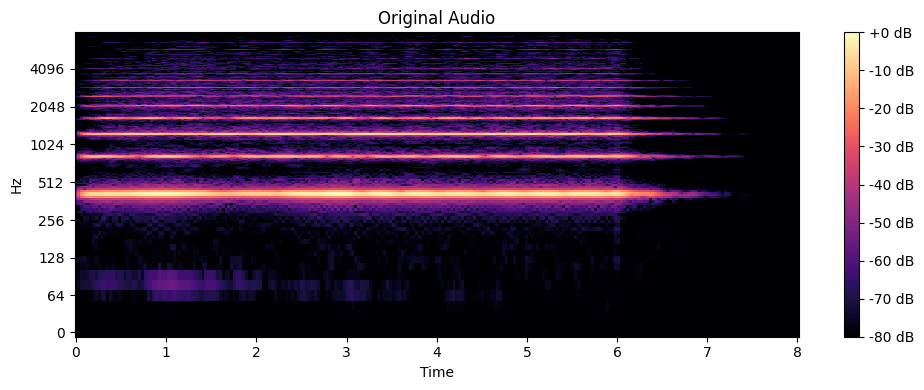

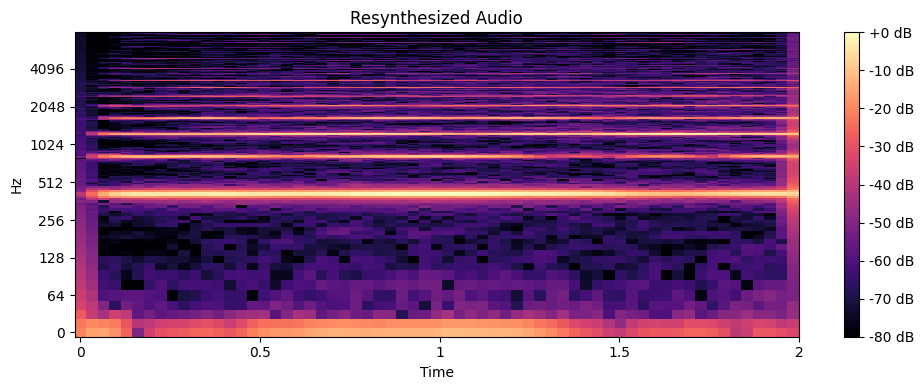

In [24]:
if hasattr(audio, "numpy"):
    y_true = audio.numpy().reshape(-1)
else:
    y_true = np.asarray(audio).reshape(-1)

audio_gen = y_pred.reshape(-1)

sf.write("original.wav", y_true, 16000)
sf.write("resynthesized.wav", audio_gen, 16000)

plot_spectrogram(y_true, "Original Audio")
plot_spectrogram(y_gen,  "Resynthesized Audio")



In [25]:
import scipy.linalg

# Performance Analysis Helper Functions:
def mag_spectrogram(y, sr, n_fft=1024, hop_length=256):
    S = librosa.stft(y, n_fft=n_fft, hop_length=hop_length, window='hann')
    return np.abs(S)

def log_spectral_distance(y_true, y_pred, sr, n_fft=1024, hop_length=256, eps=1e-8):
    S_true = mag_spectrogram(y_true, sr, n_fft, hop_length)
    S_pred = mag_spectrogram(y_pred, sr, n_fft, hop_length)
    # convert to log10 scale
    L_true = 20 * np.log10(S_true + eps)
    L_pred = 20 * np.log10(S_pred + eps)

    diff2 = (L_true - L_pred) ** 2
    lsd_frames = np.sqrt(np.mean(diff2, axis=0))
    return np.mean(lsd_frames)

def spectral_convergence(y_true, y_pred, sr, n_fft=1024, hop_length=256):
    S_true = mag_spectrogram(y_true, sr, n_fft, hop_length)
    S_pred = mag_spectrogram(y_pred, sr, n_fft, hop_length)
    num = np.linalg.norm(S_true - S_pred, ord='fro')
    den = np.linalg.norm(S_true, ord='fro') + 1e-8
    return num / den

def snr_db(y_true, y_pred, eps=1e-8):
    noise = y_true - y_pred
    power_signal = np.sum(y_true ** 2)
    power_noise  = np.sum(noise ** 2) + eps
    return 10 * np.log10(power_signal / power_noise)

def embed_mel(waveform, sr=16000, n_mels=64, n_fft=1024, hop_length=256):
    S = librosa.feature.melspectrogram(
        y=waveform,
        sr=sr,
        n_fft=n_fft,
        hop_length=hop_length,
        n_mels=n_mels,
        power=1.0
    )
    return S.T      # shape (T, n_mels)

def compute_statistics(embeddings_list):
    all_embs = np.vstack(embeddings_list)
    mu    = np.mean(all_embs, axis=0)
    sigma = np.cov(all_embs, rowvar=False)
    return mu, sigma

def frechet_distance(mu1, sigma1, mu2, sigma2, eps=1e-6):
    mu_diff = mu1 - mu2
    covmean, _ = scipy.linalg.sqrtm(sigma1 @ sigma2, disp=False)
    if not np.isfinite(covmean).all():
        offset = np.eye(sigma1.shape[0]) * eps
        covmean = scipy.linalg.sqrtm((sigma1 + offset) @ (sigma2 + offset))
    # drop tiny imaginary parts
    if np.iscomplexobj(covmean):
        covmean = covmean.real
    return (mu_diff @ mu_diff) + np.trace(sigma1 + sigma2 - 2 * covmean)

def compute_fad_mel(y_true_list, y_pred_list, sr=16000):
    # allow passing single arrays
    if isinstance(y_true_list, np.ndarray):
        y_true_list = [y_true_list]
    if isinstance(y_pred_list, np.ndarray):
        y_pred_list = [y_pred_list]

    true_embs = [embed_mel(y, sr) for y in y_true_list]
    pred_embs = [embed_mel(y, sr) for y in y_pred_list]
    mu1, sigma1 = compute_statistics(true_embs)
    mu2, sigma2 = compute_statistics(pred_embs)
    return frechet_distance(mu1, sigma1, mu2, sigma2)

In [26]:
y_true = audio.numpy().reshape(-1)
y_pred = audio_gen

# 2. Compute reconstruction-error metrics
lsd_value = log_spectral_distance(y_true, y_pred, sr=16000, n_fft=1024, hop_length=256)
sc_value  = spectral_convergence(y_true, y_pred, sr=16000, n_fft=1024, hop_length=256)
snr_value = snr_db(y_true, y_pred)
fad_score = compute_fad_mel(y_true, y_pred, sr=16000)


# 3. Print
print("PERFORMANCE METRICS")
print("==========================================================\n")
print(f"Log-Spectral Distance (LSD):      {lsd_value:.3f} dB")
print(f"Spectral Convergence:             {sc_value:.5f}")
print(f"Signal-to-Noise Ratio (SNR):      {snr_value:.2f} dB")
print(f"Frechet Audio Distance (FAD):     {fad_score:.4f}")
print("==========================================================\n")

PERFORMANCE METRICS

Log-Spectral Distance (LSD):      12.383 dB
Spectral Convergence:             0.39098
Signal-to-Noise Ratio (SNR):      7.80 dB
Frechet Audio Distance (FAD):     0.8891



In [27]:
ckpt = tf.train.Checkpoint(model=ae, optimizer=ae.optimizer)

save_path = ckpt.save("./wavenet_checkpoint")  
print("Checkpoint saved at:", save_path)

Checkpoint saved at: ./wavenet_checkpoint-1
